In [ ]:
import numpy as np
from math import pow
import matplotlib.pyplot as plt
plt.style.use('bmh')
# Set background color to antique white
plt.rcParams['axes.facecolor'] = "#F5F4F2"
import os
from utils import *
from utils import grid_to_real_projection
from simulation import *
from tqdm import tqdm
from pprint import pprint

from models import DistanceCellModel, VectorCellModel, NestedModel
from simulation import run_load_simulation
OUTPUT_DIR = 'simulation_outputs'
# ================= MODEL & SIMULATION PARAMETERS =================
#N_SIM_ROUND = 5
N_TRIALS = 100
ARENA_WIDTH = 100
STEP_SIZE = 1
CONV_THRESH = STEP_SIZE * 1.5
HEX_PROJ=True
model_names = ['nm', 'dcm', 'vcm']



{'shear-global-1': {'distortion': 'shear-global', 'a': 0, 'b': 1, 'b_drift': None}, 'shear-global-2': {'distortion': 'shear-global', 'a': 0, 'b': 2, 'b_drift': None}, 'shear-global-3': {'distortion': 'shear-global', 'a': 0, 'b': 5, 'b_drift': None}, 'shear-global-4': {'distortion': 'shear-global', 'a': 0, 'b': 10, 'b_drift': None}}

 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+ RUNNING SIMULATIONS FOR DISTORTION=shear-global-1 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+
Running new simulation for ***Nested Model*** with distortion=shear-global (a=0, b=1)...
PARAMETERS:
	M=10, min_scale=25, scale_ratio=1.5, m=20, r_max=30, poiss_time_w=0.1
	Scales=[961.08, 640.72, 427.15, 284.77, 189.84, 126.56, 84.38, 56.25, 37.5, 25.0]
	hexagonal_projection: True
OPEN FIELD: True


Simulating trials:   0%|          | 0/36 [00:00<?, ?it/s]

Simulating trials: 100%|██████████| 36/36 [00:19<00:00,  1.84it/s]


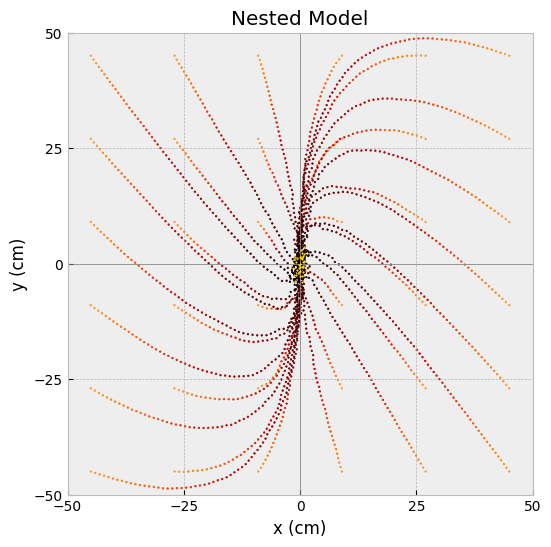

Successful trials: 36/36 (100.0%)


KeyboardInterrupt: 

In [3]:

N_SIM_ROUND = 10
N_TRIALS = 36
ARENA_WIDTH = 100
STEP_SIZE = 1
CONV_THRESH = STEP_SIZE * 1.5
HEX_PROJ=True
model_names = ['nm', 'dcm', 'vcm']

shear_global_params = get_param_dict({'a': [0], 'b': [1, 2, 5, 10]}, 
                                     'shear-global', incl_undistorted=False)
for curr_distortion_params in [shear_global_params]: #stretch_simulations + shear_simulations:
    print(curr_distortion_params)
    run_sim = True
    if run_sim: 
        for distortion_name in curr_distortion_params.keys():
            print(F'\n {"-+" * 30} RUNNING SIMULATIONS FOR DISTORTION={distortion_name} {"-+" * 30}')
            for model_name in model_names:
                x_histories, y_histories = run_load_simulation(model_name, 
                                                            arena_width=ARENA_WIDTH, 
                                                            step_size=STEP_SIZE,
                                                            convergence_threshold=CONV_THRESH,
                                                            n_trials=N_TRIALS, 
                                                            distortion_params=curr_distortion_params[distortion_name],
                                                            hexagonal_projection=HEX_PROJ,
                                                            n_sim_round=N_SIM_ROUND,
                                                            save_data=False)
                plot_trajectories(model_name, x_histories, y_histories, arena_width=ARENA_WIDTH)

        plot_trajectories_all_models(curr_distortion_params, 
                                model_names, 
                                arena_width=ARENA_WIDTH, 
                                step_size=STEP_SIZE, 
                                convergence_threshold=CONV_THRESH, 
                                n_trials=N_TRIALS, 
                                n_sim_round= N_SIM_ROUND,
                                save_fig=True)

    if not run_sim:
        plot_error_bars(curr_distortion_params,
                        model_names,
                        n_trials=N_TRIALS, 
                        n_sim_round=N_SIM_ROUND)

{'shear-global-1': {'distortion': 'shear-global', 'a': 0, 'b': 0, 'b_drift': None}, 'shear-global-2': {'distortion': 'shear-global', 'a': 0, 'b': 1, 'b_drift': None}, 'shear-global-3': {'distortion': 'shear-global', 'a': 0, 'b': 2, 'b_drift': None}, 'shear-global-4': {'distortion': 'shear-global', 'a': 0, 'b': 5, 'b_drift': None}, 'shear-global-5': {'distortion': 'shear-global', 'a': 0, 'b': 10, 'b_drift': None}}

 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+ RUNNING SIMULATIONS FOR DISTORTION=shear-global-1 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+
Running new simulation for ***Nested Model*** with distortion=shear-global (a=0, b=0)...
PARAMETERS:
	M=10, min_scale=25, scale_ratio=1.5, m=20, r_max=30, poiss_time_w=0.1
	Scales=[961.08, 640.72, 427.15, 284.77, 189.84, 126.56, 84.38, 56.25, 37.5, 25.0]
	hexagonal_projection: True
OPEN FIELD: True


Simulating trials: 100%|██████████| 36/36 [00:20<00:00,  1.77it/s]


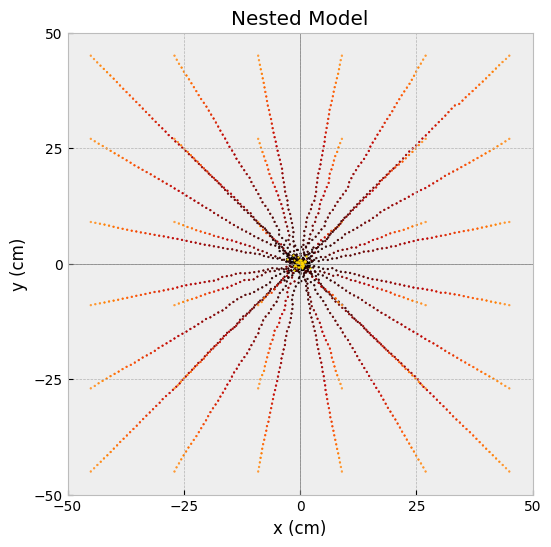

Successful trials: 36/36 (100.0%)
Running new simulation for ***Distance Cell Model*** with distortion=shear-global (a=0, b=0)...
PARAMETERS:
	M=10, min_scale=25, scale_ratio=1.5, m=20, r_max=30, poiss_time_w=0.1
	N_dc=12500 (DCM)
	xdc_positions=[[-250.   -249.96 -249.92],...,[249.88 249.92 249.96]] (DCM)
	Scales=[25.0, 37.5, 56.25, 84.38, 126.56, 189.84, 284.77, 427.15, 640.72, 961.08]
	hexagonal_projection: True
OPEN FIELD: True


Simulating trials: 100%|██████████| 36/36 [00:07<00:00,  4.78it/s]


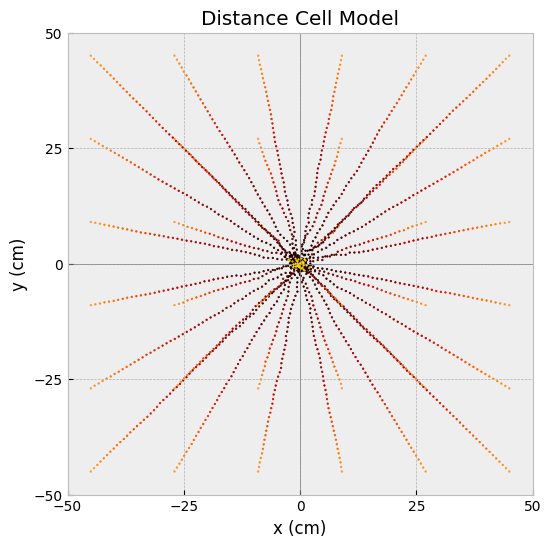

Successful trials: 36/36 (100.0%)
Running new simulation for ***Vector Cell Model*** with distortion=shear-global (a=0, b=0)...
PARAMETERS:
	M=10, min_scale=25, scale_ratio=1.5, m=20, r_max=30, poiss_time_w=0.1
	N_fvc=12500 (VCM)
	cvc_pos=[[0.         0.04411894 0.07934294],...,[497.29175374 498.64587687 500.        ]] (VCM)
	fvc_pos=[[0.        0.0400032 0.0800064],...,[499.9199936 499.9599968 500.       ]] (VCM)
	Scales=[25.0, 37.5, 56.25, 84.38, 126.56, 189.84, 284.77, 427.15, 640.72, 961.08]
	hexagonal_projection: True
OPEN FIELD: True


Simulating trials: 100%|██████████| 36/36 [01:44<00:00,  2.89s/it]


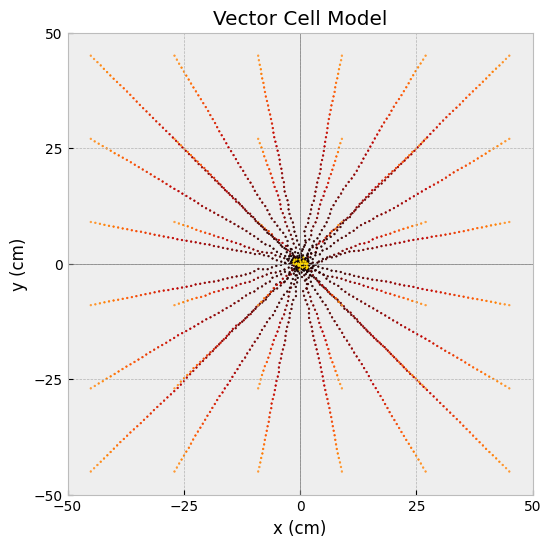

Successful trials: 36/36 (100.0%)

 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+ RUNNING SIMULATIONS FOR DISTORTION=shear-global-2 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+
Running new simulation for ***Nested Model*** with distortion=shear-global (a=0, b=1)...
PARAMETERS:
	M=10, min_scale=25, scale_ratio=1.5, m=20, r_max=30, poiss_time_w=0.1
	Scales=[961.08, 640.72, 427.15, 284.77, 189.84, 126.56, 84.38, 56.25, 37.5, 25.0]
	hexagonal_projection: True
OPEN FIELD: True


Simulating trials: 100%|██████████| 36/36 [00:17<00:00,  2.05it/s]


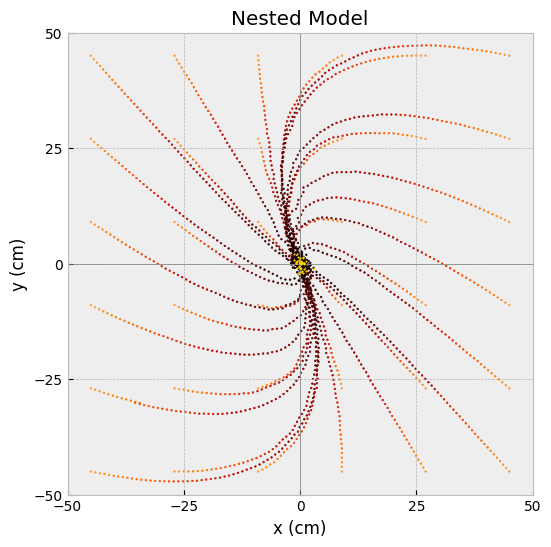

Successful trials: 36/36 (100.0%)
Running new simulation for ***Distance Cell Model*** with distortion=shear-global (a=0, b=1)...
PARAMETERS:
	M=10, min_scale=25, scale_ratio=1.5, m=20, r_max=30, poiss_time_w=0.1
	N_dc=12500 (DCM)
	xdc_positions=[[-250.   -249.96 -249.92],...,[249.88 249.92 249.96]] (DCM)
	Scales=[25.0, 37.5, 56.25, 84.38, 126.56, 189.84, 284.77, 427.15, 640.72, 961.08]
	hexagonal_projection: True
OPEN FIELD: True


Simulating trials: 100%|██████████| 36/36 [00:08<00:00,  4.09it/s]


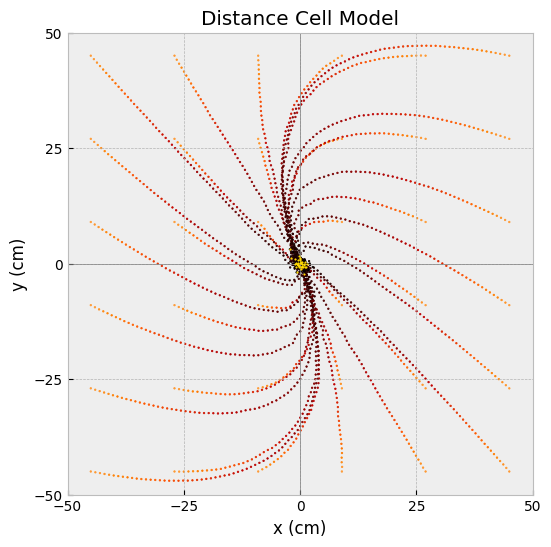

Successful trials: 36/36 (100.0%)
Running new simulation for ***Vector Cell Model*** with distortion=shear-global (a=0, b=1)...
PARAMETERS:
	M=10, min_scale=25, scale_ratio=1.5, m=20, r_max=30, poiss_time_w=0.1
	N_fvc=12500 (VCM)
	cvc_pos=[[0.         0.04411894 0.07934294],...,[497.29175374 498.64587687 500.        ]] (VCM)
	fvc_pos=[[0.        0.0400032 0.0800064],...,[499.9199936 499.9599968 500.       ]] (VCM)
	Scales=[25.0, 37.5, 56.25, 84.38, 126.56, 189.84, 284.77, 427.15, 640.72, 961.08]
	hexagonal_projection: True
OPEN FIELD: True


Simulating trials: 100%|██████████| 36/36 [02:17<00:00,  3.82s/it]


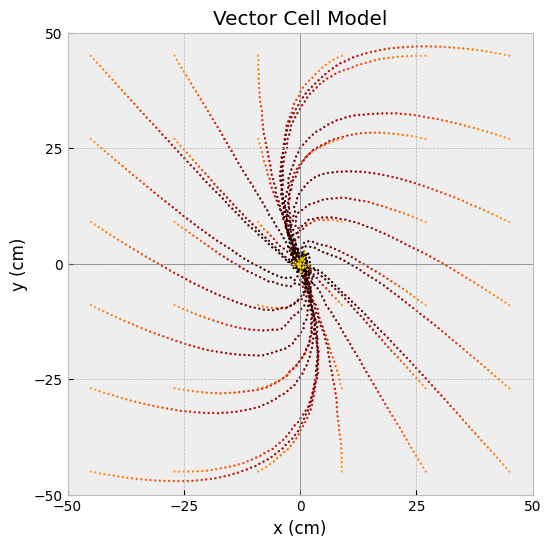

Successful trials: 36/36 (100.0%)

 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+ RUNNING SIMULATIONS FOR DISTORTION=shear-global-3 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+
Running new simulation for ***Nested Model*** with distortion=shear-global (a=0, b=2)...
PARAMETERS:
	M=10, min_scale=25, scale_ratio=1.5, m=20, r_max=30, poiss_time_w=0.1
	Scales=[961.08, 640.72, 427.15, 284.77, 189.84, 126.56, 84.38, 56.25, 37.5, 25.0]
	hexagonal_projection: True
OPEN FIELD: True


Simulating trials: 100%|██████████| 36/36 [00:25<00:00,  1.43it/s]


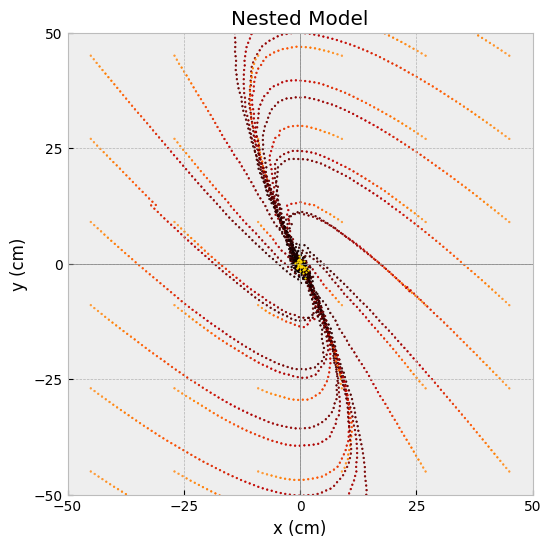

Successful trials: 36/36 (100.0%)
Running new simulation for ***Distance Cell Model*** with distortion=shear-global (a=0, b=2)...
PARAMETERS:
	M=10, min_scale=25, scale_ratio=1.5, m=20, r_max=30, poiss_time_w=0.1
	N_dc=12500 (DCM)
	xdc_positions=[[-250.   -249.96 -249.92],...,[249.88 249.92 249.96]] (DCM)
	Scales=[25.0, 37.5, 56.25, 84.38, 126.56, 189.84, 284.77, 427.15, 640.72, 961.08]
	hexagonal_projection: True
OPEN FIELD: True


Simulating trials: 100%|██████████| 36/36 [00:12<00:00,  2.90it/s]


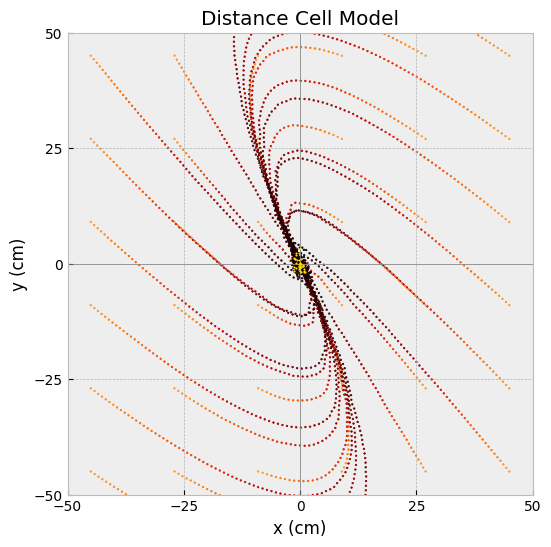

Successful trials: 36/36 (100.0%)
Running new simulation for ***Vector Cell Model*** with distortion=shear-global (a=0, b=2)...
PARAMETERS:
	M=10, min_scale=25, scale_ratio=1.5, m=20, r_max=30, poiss_time_w=0.1
	N_fvc=12500 (VCM)
	cvc_pos=[[0.         0.04411894 0.07934294],...,[497.29175374 498.64587687 500.        ]] (VCM)
	fvc_pos=[[0.        0.0400032 0.0800064],...,[499.9199936 499.9599968 500.       ]] (VCM)
	Scales=[25.0, 37.5, 56.25, 84.38, 126.56, 189.84, 284.77, 427.15, 640.72, 961.08]
	hexagonal_projection: True
OPEN FIELD: True


Simulating trials: 100%|██████████| 36/36 [02:37<00:00,  4.38s/it]


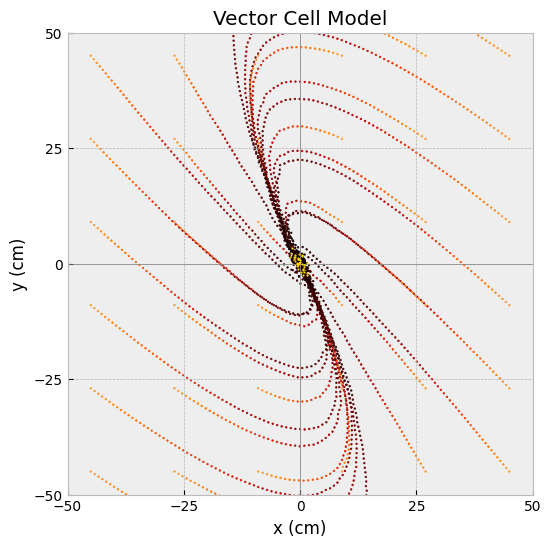

Successful trials: 36/36 (100.0%)

 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+ RUNNING SIMULATIONS FOR DISTORTION=shear-global-4 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+
Running new simulation for ***Nested Model*** with distortion=shear-global (a=0, b=5)...
PARAMETERS:
	M=10, min_scale=25, scale_ratio=1.5, m=20, r_max=30, poiss_time_w=0.1
	Scales=[961.08, 640.72, 427.15, 284.77, 189.84, 126.56, 84.38, 56.25, 37.5, 25.0]
	hexagonal_projection: True
OPEN FIELD: True


Simulating trials: 100%|██████████| 36/36 [00:56<00:00,  1.57s/it]


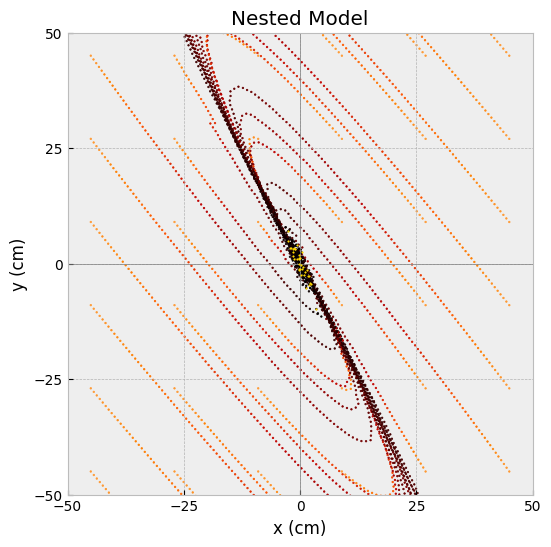

Successful trials: 36/36 (100.0%)
Running new simulation for ***Distance Cell Model*** with distortion=shear-global (a=0, b=5)...
PARAMETERS:
	M=10, min_scale=25, scale_ratio=1.5, m=20, r_max=30, poiss_time_w=0.1
	N_dc=12500 (DCM)
	xdc_positions=[[-250.   -249.96 -249.92],...,[249.88 249.92 249.96]] (DCM)
	Scales=[25.0, 37.5, 56.25, 84.38, 126.56, 189.84, 284.77, 427.15, 640.72, 961.08]
	hexagonal_projection: True
OPEN FIELD: True


Simulating trials: 100%|██████████| 36/36 [00:21<00:00,  1.68it/s]


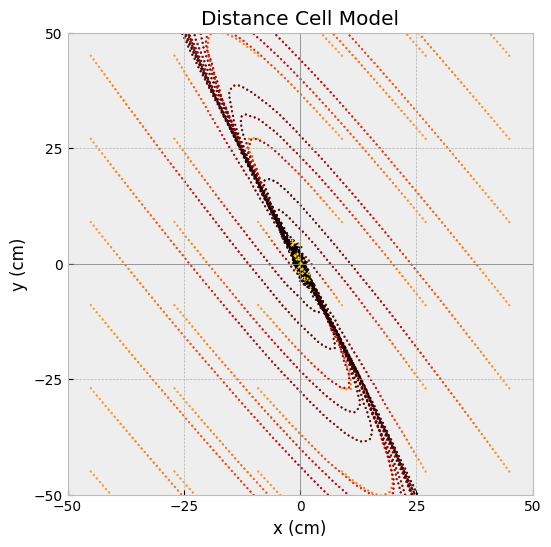

Successful trials: 36/36 (100.0%)
Running new simulation for ***Vector Cell Model*** with distortion=shear-global (a=0, b=5)...
PARAMETERS:
	M=10, min_scale=25, scale_ratio=1.5, m=20, r_max=30, poiss_time_w=0.1
	N_fvc=12500 (VCM)
	cvc_pos=[[0.         0.04411894 0.07934294],...,[497.29175374 498.64587687 500.        ]] (VCM)
	fvc_pos=[[0.        0.0400032 0.0800064],...,[499.9199936 499.9599968 500.       ]] (VCM)
	Scales=[25.0, 37.5, 56.25, 84.38, 126.56, 189.84, 284.77, 427.15, 640.72, 961.08]
	hexagonal_projection: True
OPEN FIELD: True


Simulating trials: 100%|██████████| 36/36 [05:55<00:00,  9.88s/it]


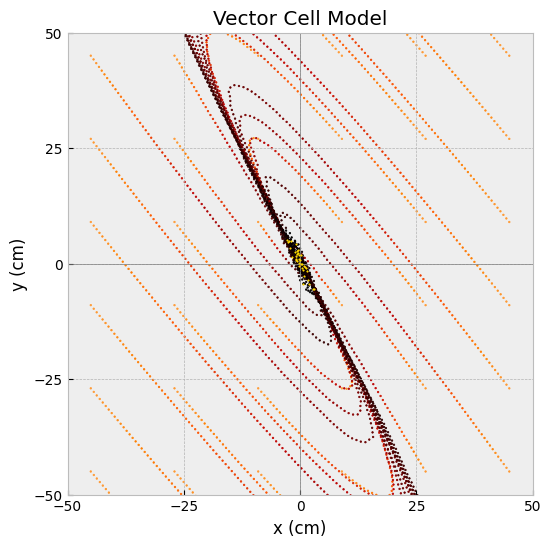

Successful trials: 36/36 (100.0%)

 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+ RUNNING SIMULATIONS FOR DISTORTION=shear-global-5 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+
Running new simulation for ***Nested Model*** with distortion=shear-global (a=0, b=10)...
PARAMETERS:
	M=10, min_scale=25, scale_ratio=1.5, m=20, r_max=30, poiss_time_w=0.1
	Scales=[961.08, 640.72, 427.15, 284.77, 189.84, 126.56, 84.38, 56.25, 37.5, 25.0]
	hexagonal_projection: True
OPEN FIELD: True


Simulating trials: 100%|██████████| 36/36 [01:13<00:00,  2.05s/it]


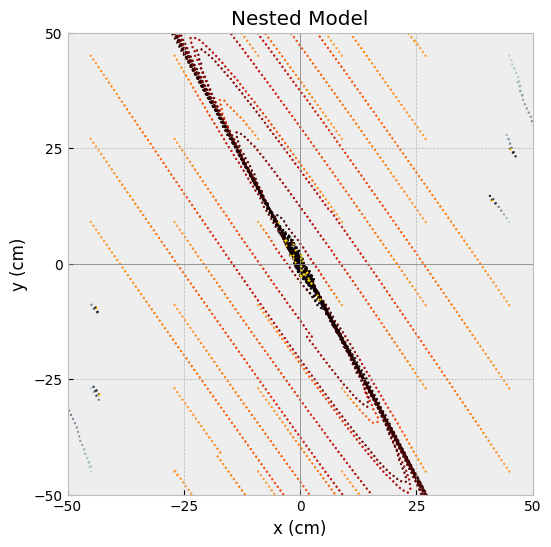

Successful trials: 30/36 (83.3%)
Running new simulation for ***Distance Cell Model*** with distortion=shear-global (a=0, b=10)...
PARAMETERS:
	M=10, min_scale=25, scale_ratio=1.5, m=20, r_max=30, poiss_time_w=0.1
	N_dc=12500 (DCM)
	xdc_positions=[[-250.   -249.96 -249.92],...,[249.88 249.92 249.96]] (DCM)
	Scales=[25.0, 37.5, 56.25, 84.38, 126.56, 189.84, 284.77, 427.15, 640.72, 961.08]
	hexagonal_projection: True
OPEN FIELD: True


Simulating trials: 100%|██████████| 36/36 [00:19<00:00,  1.87it/s]


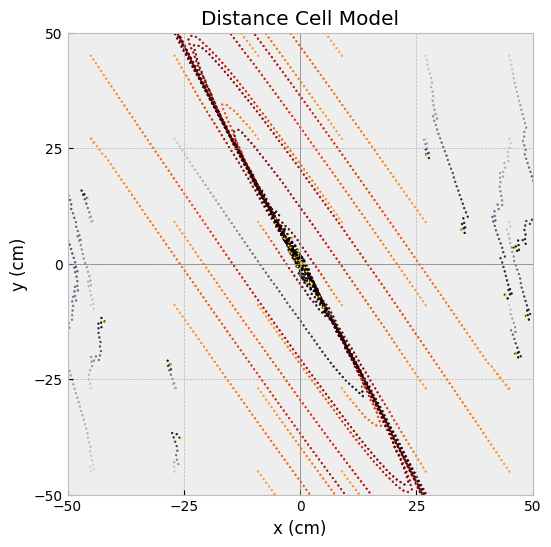

Successful trials: 23/36 (63.9%)
Running new simulation for ***Vector Cell Model*** with distortion=shear-global (a=0, b=10)...
PARAMETERS:
	M=10, min_scale=25, scale_ratio=1.5, m=20, r_max=30, poiss_time_w=0.1
	N_fvc=12500 (VCM)
	cvc_pos=[[0.         0.04411894 0.07934294],...,[497.29175374 498.64587687 500.        ]] (VCM)
	fvc_pos=[[0.        0.0400032 0.0800064],...,[499.9199936 499.9599968 500.       ]] (VCM)
	Scales=[25.0, 37.5, 56.25, 84.38, 126.56, 189.84, 284.77, 427.15, 640.72, 961.08]
	hexagonal_projection: True
OPEN FIELD: True


Simulating trials: 100%|██████████| 36/36 [07:38<00:00, 12.74s/it]


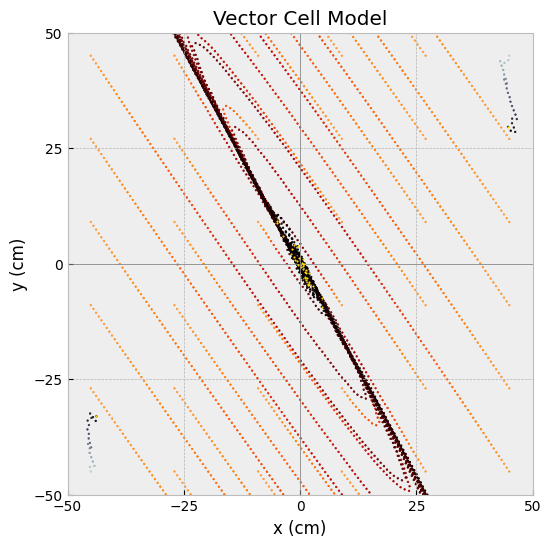

Successful trials: 34/36 (94.4%)
guuuuee0000ee b
--guuuuee0000ee \beta
ERROR: Simulation data file simulation_outputs/round-9/global/nm_trials-36_shear-global_a-0_b-0.pkl does not exist. Please run the simulation first.


TypeError: cannot unpack non-iterable NoneType object

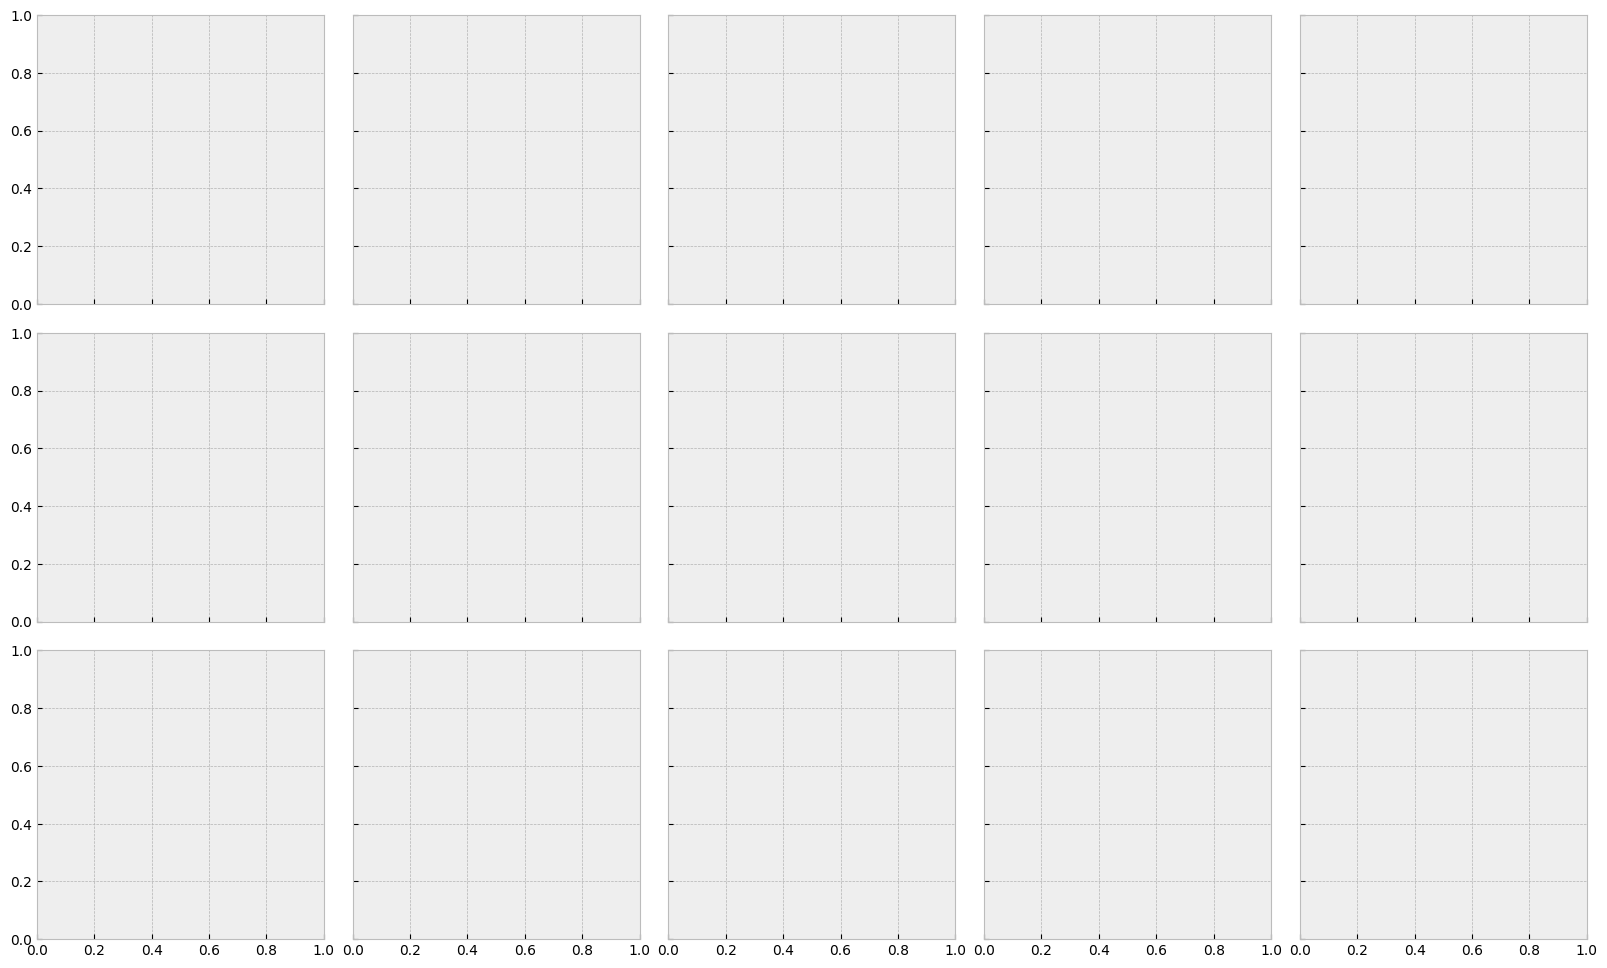

In [ ]:
# ================= MODEL & SIMULATION PARAMETERS =================
N_SIM_ROUND = 9
N_TRIALS = 36
ARENA_WIDTH = 100
STEP_SIZE = 1
CONV_THRESH = STEP_SIZE * 1.5
HEX_PROJ=True
model_names = ['nm', 'dcm', 'vcm']

no_distortion_params = {'undistorted-0': {'distortion': 'none-global', 'a': None, 'b':None}}
example_distortion_params = {'undistorted-0': {'distortion': 'none-global', 'a': None, 'b':None},
                     'shear1': {'distortion': 'shear', 'a': 0, 'b': 0.3},
                     'stretch1': {'distortion': 'stretch', 'a': 1, 'b': 0.67}}

# Global distortion parameters
shear_drift_global_params = get_param_dict({'a': [0], 'b': [0, 1, 2, 5, 10], 'b_drift': [0.1]}, 
                                     'shear+drift-global', incl_undistorted=False)

shear_global_params = get_param_dict({'a': [0], 'b': [0, 1, 2, 5, 10]}, 
                                     'shear-global', incl_undistorted=False)
stretch_global_params = get_param_dict({'a': [1], 'b': [1, 0.7, 0.5, 0.3, 0.1]}, 
                                       'stretch-global', incl_undistorted=False)

# Local distortion parameters
shear_local_params = get_param_dict({'a': [0], 'b': [0, 0.05, 0.1, 0.3, 0.5]}, 
                                     'shear-local', incl_undistorted=False)
stretch_local_params = get_param_dict({'a': [1], 'b': [1, 0.99, 0.95, 0.9, 0.7]}, 
                                       'stretch-local', incl_undistorted=False)

# Modular distortion parameters
shear_modular_params = get_param_dict({'a': [0], 'b': [0, 1, 2, 5, 10]}, 
                                'shear-modular', incl_undistorted=False)
stretch_modular_params = get_param_dict({'a': [1], 'b': [0, 0.3, 0.5, 0.7, 0.9]},  # WARNING: Here b_final is 1 - b, so at b=0.5 we'd have b_M's = [0.99, 0.98, 0.97, 0.96, 0.93, 0.9 , 0.85, 0.78, 0.67, 0.5 ]
                                'stretch-modular', incl_undistorted=False)

stretch_simulations = [stretch_global_params, stretch_modular_params, stretch_local_params]
shear_simulations = [shear_global_params, shear_modular_params, shear_local_params, shear_drift_global_params]

for curr_distortion_params in [shear_global_params]: #stretch_simulations + shear_simulations:
    print(curr_distortion_params)
    run_sim = True
    if run_sim: 
        for distortion_name in curr_distortion_params.keys():
            print(F'\n {"-+" * 30} RUNNING SIMULATIONS FOR DISTORTION={distortion_name} {"-+" * 30}')
            for model_name in model_names:
                x_histories, y_histories = run_load_simulation(model_name, 
                                                            arena_width=ARENA_WIDTH, 
                                                            step_size=STEP_SIZE,
                                                            convergence_threshold=CONV_THRESH,
                                                            n_trials=N_TRIALS, 
                                                            distortion_params=curr_distortion_params[distortion_name],
                                                            hexagonal_projection=HEX_PROJ,
                                                            n_sim_round=N_SIM_ROUND,
                                                            save_data=False)
                plot_trajectories(model_name, x_histories, y_histories, arena_width=ARENA_WIDTH)

        plot_trajectories_all_models(curr_distortion_params, 
                                model_names, 
                                arena_width=ARENA_WIDTH, 
                                step_size=STEP_SIZE, 
                                convergence_threshold=CONV_THRESH, 
                                n_trials=N_TRIALS, 
                                n_sim_round= N_SIM_ROUND,
                                save_fig=True)

    if not run_sim:
        plot_error_bars(curr_distortion_params,
                        model_names,
                        n_trials=N_TRIALS, 
                        n_sim_round=N_SIM_ROUND)
aksdnjfksadjnf

In [ ]:

# =================================================================

for curr_distortion_params in [shear_drift_global_params]:
    print(curr_distortion_params)
    run_sim = True
    if run_sim: 
        for distortion_name in curr_distortion_params.keys():
            print(F'\n {"-+" * 30} RUNNING SIMULATIONS FOR DISTORTION={distortion_name} {"-+" * 30}')
            for model_name in model_names:
                x_histories, y_histories = run_load_simulation(model_name, 
                                                            arena_width=ARENA_WIDTH, 
                                                            step_size=STEP_SIZE,
                                                            convergence_threshold=CONV_THRESH,
                                                            n_trials=N_TRIALS, 
                                                            distortion_params=curr_distortion_params[distortion_name],
                                                            hexagonal_projection=HEX_PROJ,
                                                            n_sim_round=N_SIM_ROUND,
                                                            save_data=True)

    if not run_sim:
        if False:
            plot_trajectories_all_models(curr_distortion_params, 
                                    model_names, 
                                    arena_width=ARENA_WIDTH, 
                                    step_size=STEP_SIZE, 
                                    convergence_threshold=CONV_THRESH, 
                                    n_trials=N_TRIALS, 
                                    n_sim_round= N_SIM_ROUND,
                                    save_fig=True)
        plot_error_bars(curr_distortion_params,
                        model_names,
                        n_trials=N_TRIALS, 
                        n_sim_round=N_SIM_ROUND)
aksdnjfksadjnf

{'shear+drift-global-1': {'distortion': 'shear+drift-global', 'a': 0, 'b': 0, 'b_drift': 0.1}, 'shear+drift-global-2': {'distortion': 'shear+drift-global', 'a': 0, 'b': 1, 'b_drift': 0.1}, 'shear+drift-global-3': {'distortion': 'shear+drift-global', 'a': 0, 'b': 2, 'b_drift': 0.1}, 'shear+drift-global-4': {'distortion': 'shear+drift-global', 'a': 0, 'b': 5, 'b_drift': 0.1}, 'shear+drift-global-5': {'distortion': 'shear+drift-global', 'a': 0, 'b': 10, 'b_drift': 0.1}}

 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+ RUNNING SIMULATIONS FOR DISTORTION=shear+drift-global-1 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+

 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+ RUNNING SIMULATIONS FOR DISTORTION=shear+drift-global-2 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+

 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+ RUNNING SIMULATIONS FOR DISTORTION=shear+drift-global-3 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-

Simulating trials: 100%|██████████| 100/100 [04:59<00:00,  2.99s/it]

Saved simulation data to simulation_outputs/round-8/global/vcm_trials-100_shear+drift-global_a-0_b-10_bdrift-0.1.pkl



NameError: name 'aksdnjfksadjnf' is not defined

In [ ]:
# ----------------------------------------------------------------#
N_SIM_ROUND = 8
N_TRIALS = 100
stretch_global_params = get_param_dict({'a': [1], 'b': [1]}, 
                                       'stretch-global', incl_undistorted=False)
selected_distortion_params = stretch_global_params
for distortion_name in selected_distortion_params.keys():
    print(F'\n {"-+" * 30} RUNNING SIMULATIONS FOR DISTORTION={distortion_name} {"-+" * 30}')
    for model_name in ['vcm']:
        x_histories, y_histories = run_load_simulation(model_name, 
                                                    arena_width=ARENA_WIDTH, 
                                                    step_size=STEP_SIZE,
                                                    convergence_threshold=CONV_THRESH,
                                                    n_trials=N_TRIALS, 
                                                    distortion_params=selected_distortion_params[distortion_name],
                                                    hexagonal_projection=HEX_PROJ,
                                                    n_sim_round= N_SIM_ROUND,
                                                    save_data=False)
        plot_trajectories(model_name, x_histories, y_histories, arena_width=ARENA_WIDTH)

In [ ]:
plot_error_bars(distortion='shear-global', distortion_params=shear_global_params, n_trials=N_TRIALS, model_names=model_names)
plot_error_bars(distortion='shear-modular', distortion_params=shear_modular_params, n_trials=N_TRIALS, model_names=model_names)
plot_error_bars(distortion='shear-local', distortion_params=shear_local_params, n_trials=N_TRIALS, model_names=model_names)

In [ ]:
arena_width = 100
n_trials = 100
border_offset = 0.05 * arena_width
square_half_width = (arena_width / 2)
offset_square_half_width = square_half_width - border_offset

XS = np.linspace(-offset_square_half_width, offset_square_half_width, int(np.sqrt(n_trials)))
YS = np.linspace(-offset_square_half_width, offset_square_half_width, int(np.sqrt(n_trials)))
start_locs = np.array(np.meshgrid(XS, YS)).T.reshape(-1, 2)
print('start_locs:', start_locs.shape)

print('Projecting evenly spaced start locations onto hexagonal grid axes...')
PX, PY = np.meshgrid(XS, YS)
original_grid = np.array([PX.ravel(), PY.ravel()])  # (2, N) — evenly spaced in axis space
start_locs = project_onto_axis_back(original_grid, l1=1, l2=2)  # (2, N) — parallelogram in real space
start_locs = start_locs.T  # (N, 2)
print('start_locs:', start_locs.shape)


start_locs: (100, 2)
Projecting evenly spaced start locations onto hexagonal grid axes...
start_locs: (100, 2)


### Projection of coordinate system into GC space

In [ ]:
offset_square_half_width = 10
n_trials = 10
xs = np.linspace(-offset_square_half_width, offset_square_half_width, int(np.sqrt(n_trials)))
ys = np.linspace(-offset_square_half_width, offset_square_half_width, int(np.sqrt(n_trials)))
XS, YS = np.meshgrid(xs, ys)
real_start_locs = np.array([XS.ravel(), YS.ravel()]).T.reshape(-1, 2)
real_start_locs


array([[-10., -10.],
       [  0.,   0.],
       [ 10.,  10.]])

In [ ]:
def gc_distortion(X, Y, distortion, a=None, b=None, reverse_distortion=False):
    '''Applied distortion to X and Y coordinates.'''
    if distortion == 'stretch':
        dist_mat = np.array([[a, 0], [0, b]])
        inv_dist_mat = np.linalg.inv(dist_mat)
        X_new = inv_dist_mat[0,0]*X + inv_dist_mat[0,1]*Y
        Y_new = inv_dist_mat[1,0]*X + inv_dist_mat[1,1]*Y
        if reverse_distortion:
            X_new = dist_mat[0,0]*X + dist_mat[0,1]*Y
            Y_new = dist_mat[1,0]*X + dist_mat[1,1]*Y
    elif distortion == 'shear':
        dist_mat = np.array([[1, a], [b, 1]])
        inv_dist_mat = np.linalg.inv(dist_mat)
        X_new = inv_dist_mat[0,0]*X + inv_dist_mat[0,1]*Y
        Y_new = inv_dist_mat[1,0]*X + inv_dist_mat[1,1]*Y
        if reverse_distortion:
            X_new = dist_mat[0,0]*X + dist_mat[0,1]*Y
            Y_new = dist_mat[1,0]*X + dist_mat[1,1]*Y
    elif distortion == 'symmetric':
        X_new = X / (1 + a)
        Y_new = Y / (1 + (a * X / (1 + a)))  
    elif distortion is None or distortion == 'None':
        X_new = X
        Y_new = Y
    return X_new, Y_new

In [ ]:
dist_grid_vecs

[array([25.98076211, 64.28571429]),
 array([14.43375673, 64.28571429]),
 array([ 2.88675135, 64.28571429]),
 array([-8.66025404, 64.28571429]),
 array([-20.20725942,  64.28571429]),
 array([-31.75426481,  64.28571429]),
 array([-43.30127019,  64.28571429]),
 array([-54.84827557,  64.28571429]),
 array([-66.39528096,  64.28571429]),
 array([-77.94228634,  64.28571429]),
 array([31.75426481, 50.        ]),
 array([20.20725942, 50.        ]),
 array([ 8.66025404, 50.        ]),
 array([-2.88675135, 50.        ]),
 array([-14.43375673,  50.        ]),
 array([-25.98076211,  50.        ]),
 array([-37.5277675,  50.       ]),
 array([-49.07477288,  50.        ]),
 array([-60.62177826,  50.        ]),
 array([-72.16878365,  50.        ]),
 array([37.5277675 , 35.71428571]),
 array([25.98076211, 35.71428571]),
 array([14.43375673, 35.71428571]),
 array([ 2.88675135, 35.71428571]),
 array([-8.66025404, 35.71428571]),
 array([-20.20725942,  35.71428571]),
 array([-31.75426481,  35.71428571]),
 a

In [ ]:
dist_grid_vecs = np.array(dist_grid_vecs)
dist_grid_vecs[:,0]


array([ 25.98076211,  14.43375673,   2.88675135,  -8.66025404,
       -20.20725942, -31.75426481, -43.30127019, -54.84827557,
       -66.39528096, -77.94228634,  31.75426481,  20.20725942,
         8.66025404,  -2.88675135, -14.43375673, -25.98076211,
       -37.5277675 , -49.07477288, -60.62177826, -72.16878365,
        37.5277675 ,  25.98076211,  14.43375673,   2.88675135,
        -8.66025404, -20.20725942, -31.75426481, -43.30127019,
       -54.84827557, -66.39528096,  43.30127019,  31.75426481,
        20.20725942,   8.66025404,  -2.88675135, -14.43375673,
       -25.98076211, -37.5277675 , -49.07477288, -60.62177826,
        49.07477288,  37.5277675 ,  25.98076211,  14.43375673,
         2.88675135,  -8.66025404, -20.20725942, -31.75426481,
       -43.30127019, -54.84827557,  54.84827557,  43.30127019,
        31.75426481,  20.20725942,   8.66025404,  -2.88675135,
       -14.43375673, -25.98076211, -37.5277675 , -49.07477288,
        60.62177826,  49.07477288,  37.5277675 ,  25.98

In [ ]:
proj_grid

array([[-25.98076211, -14.43375673,  -2.88675135,   8.66025404,
         20.20725942,  31.75426481,  43.30127019,  54.84827557,
         66.39528096,  77.94228634, -31.75426481, -20.20725942,
         -8.66025404,   2.88675135,  14.43375673,  25.98076211,
         37.5277675 ,  49.07477288,  60.62177826,  72.16878365,
        -37.5277675 , -25.98076211, -14.43375673,  -2.88675135,
          8.66025404,  20.20725942,  31.75426481,  43.30127019,
         54.84827557,  66.39528096, -43.30127019, -31.75426481,
        -20.20725942,  -8.66025404,   2.88675135,  14.43375673,
         25.98076211,  37.5277675 ,  49.07477288,  60.62177826,
        -49.07477288, -37.5277675 , -25.98076211, -14.43375673,
         -2.88675135,   8.66025404,  20.20725942,  31.75426481,
         43.30127019,  54.84827557, -54.84827557, -43.30127019,
        -31.75426481, -20.20725942,  -8.66025404,   2.88675135,
         14.43375673,  25.98076211,  37.5277675 ,  49.07477288,
        -60.62177826, -49.07477288, -37.

In [ ]:
# Get rid of extra dim
[vec for vec in dist_grid_vecs]

[array([25.98076211, 64.28571429]),
 array([14.43375673, 64.28571429]),
 array([ 2.88675135, 64.28571429]),
 array([-8.66025404, 64.28571429]),
 array([-20.20725942,  64.28571429]),
 array([-31.75426481,  64.28571429]),
 array([-43.30127019,  64.28571429]),
 array([-54.84827557,  64.28571429]),
 array([-66.39528096,  64.28571429]),
 array([-77.94228634,  64.28571429]),
 array([31.75426481, 50.        ]),
 array([20.20725942, 50.        ]),
 array([ 8.66025404, 50.        ]),
 array([-2.88675135, 50.        ]),
 array([-14.43375673,  50.        ]),
 array([-25.98076211,  50.        ]),
 array([-37.5277675,  50.       ]),
 array([-49.07477288,  50.        ]),
 array([-60.62177826,  50.        ]),
 array([-72.16878365,  50.        ]),
 array([37.5277675 , 35.71428571]),
 array([25.98076211, 35.71428571]),
 array([14.43375673, 35.71428571]),
 array([ 2.88675135, 35.71428571]),
 array([-8.66025404, 35.71428571]),
 array([-20.20725942,  35.71428571]),
 array([-31.75426481,  35.71428571]),
 a

In [ ]:
normal_grid_vecs = np.array(normal_grid_vecs)
normal_grid_vecs.shape

(100, 2)

In [ ]:
real_grid_diff.shape

(2, 100)

In [ ]:
est_goal_locs = normal_grid_vecs + proj_grid.T

array([[20., 40.],
       [20., 40.],
       [20., 40.],
       [20., 40.],
       [20., 40.],
       [20., 40.],
       [20., 40.],
       [20., 40.],
       [20., 40.],
       [20., 40.],
       [20., 40.],
       [20., 40.],
       [20., 40.],
       [20., 40.],
       [20., 40.],
       [20., 40.],
       [20., 40.],
       [20., 40.],
       [20., 40.],
       [20., 40.],
       [20., 40.],
       [20., 40.],
       [20., 40.],
       [20., 40.],
       [20., 40.],
       [20., 40.],
       [20., 40.],
       [20., 40.],
       [20., 40.],
       [20., 40.],
       [20., 40.],
       [20., 40.],
       [20., 40.],
       [20., 40.],
       [20., 40.],
       [20., 40.],
       [20., 40.],
       [20., 40.],
       [20., 40.],
       [20., 40.],
       [20., 40.],
       [20., 40.],
       [20., 40.],
       [20., 40.],
       [20., 40.],
       [20., 40.],
       [20., 40.],
       [20., 40.],
       [20., 40.],
       [20., 40.],
       [20., 40.],
       [20., 40.],
       [20.,

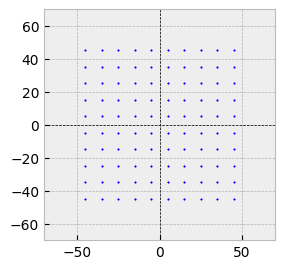

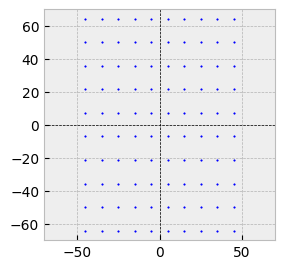

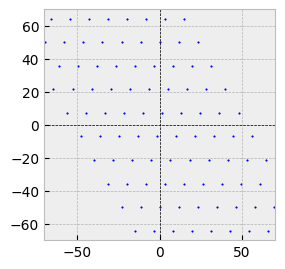

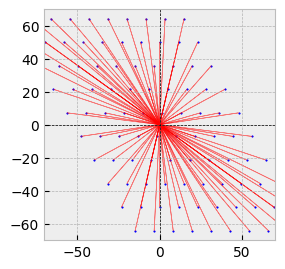

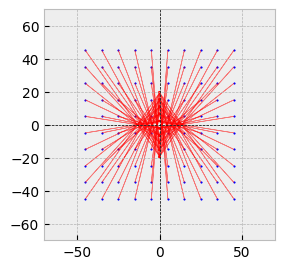

In [17]:
def plot_start_locations(X, Y, square_half_width, all_vecs = None, plot_vecs = False, title='Start Locations in Arena', distortion=False):
    plt.figure(figsize=(3, 3))
    if distortion == True and 'Grid Space' in title and False:
        X, Y = gc_distortion(X, Y, distortion='shear', a=0, b=1)
    plt.scatter(X, Y, c='blue', label='Start Locations', s=1)
    box_lim = 70
    plt.xlim(-box_lim, box_lim)
    plt.ylim(-box_lim, box_lim)
    # Calculate vector from each point to [0,0]
    no_loaded_all_vecs = all_vecs is None
    all_vecs = [] if no_loaded_all_vecs else all_vecs
    if plot_vecs:
        for i, (x, y) in enumerate(zip(X, Y)):
            if no_loaded_all_vecs:
                my_vec = - np.array([x, y])
                all_vecs.append(my_vec)
            else:
                my_vec = all_vecs[i]

                # Apply reverse distortion to the vector if distortion is applied
               # if distortion:
               #     print(f'Applying reverse distortion to vector {i}: {my_vec}')
               #     my_vec[0], my_vec[1] = gc_distortion(my_vec[0], my_vec[1], distortion='shear', a=0, b=2)
                # normalize
            plt.arrow(x, y, my_vec[0], my_vec[1], head_width=1, head_length=1, fc='red', ec='red', alpha=0.5)
    plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
    plt.axvline(0, color='black', linewidth=0.5, linestyle='--')
  #  plt.title(title)
  #  plt.xlabel('X')
  #  plt.ylabel('Y')
    plt.gca().set_aspect('equal', adjustable='box')
    plt.grid(True)
    return all_vecs

    
# 1. Grid of start locations in real space
arena_width = 100
n_trials = 100

square_half_width = (arena_width / 2)
offset = 0.1 * square_half_width  # to avoid points on the edge

# Generate pos_xy_mat
XS = np.linspace(-square_half_width + offset, square_half_width - offset, int(np.sqrt(n_trials)))
YS = np.linspace(-square_half_width + offset, square_half_width - offset, int(np.sqrt(n_trials)))
PX, PY = np.meshgrid(XS, YS)
start_real = np.array([PX.ravel(), PY.ravel()])  # (2, N) — evenly spaced in axis space

_ = plot_start_locations(start_real[0, :], start_real[1, :], square_half_width, title='Original Start Locations in Real Space')
#X_pert, Y_pert = gc_distortion(start_real[0, :], start_real[1, :], distortion='shear', a=0, b=10)
X_pert, Y_pert = gc_distortion(start_real[0, :], start_real[1, :], distortion='stretch', a=1, b=0.7)
start_pert_real = np.array([X_pert, Y_pert])  # (2, N) — evenly spaced in axis space
_ = plot_start_locations(start_pert_real[0, :], start_pert_real[1, :], square_half_width, title='Perturbed Start Locations in Real Space')

# Convert to real 2D positions to pass to navigation
start_pert_grid = grid_to_real_projection(start_pert_real, l1=1, l2=2)  # (2, N) — parallelogram in real space

_ = plot_start_locations(start_pert_grid[0, :], start_pert_grid[1, :], square_half_width,  plot_vecs=False, title='Perturbed Start Locations in Grid Space')

#vecs_grid = plot_start_locations(start_grid[0, :], start_grid[1, :], square_half_width,  plot_vecs=False, title='Start Locations in Grid Space', distortion=True)
#vecs_grid = plot_start_locations(start_grid[0, :], start_grid[1, :], square_half_width,  plot_vecs=True, title='Start Locations in Distorted Grid Space')
pert_vecs_grid = plot_start_locations(start_pert_grid[0, :], start_pert_grid[1, :], square_half_width,  plot_vecs=True, title='Perturbed Start Locations in Grid Space')
#vecs_grid = plot_start_locations(start_grid[0, :], start_grid[1, :], square_half_width,  plot_vecs=True, all_vecs=vecs_grid, title='Start Locations in Grid Space', distortion=False)
pert_vecs_grid = np.array(pert_vecs_grid)

#_ = plot_start_locations(start_grid[0, :], start_grid[1, :], square_half_width, title='Applying stretch distortion to Locations in Grid Space', distortion= True)

#grid_vecs = plot_start_locations(start_grid[0, :], start_grid[1, :], square_half_width, plot_vecs=True, title='Calculating Vectors in Grid Space', distortion= True)

#print('This should match my original start locations:')
#normal_grid_vecs = grid_to_real_projection(vecs_grid)

#real_grid_start_diff = start_real - start_grid
#goal_grid = vecs_grid + start_grid.T
#goal_real = real_to_grid_projection(goal_grid.T).T
#real_grid_goal_diff = goal_real - goal_grid
#corrected_normal_grid_vecs = vecs_grid - real_grid_start_diff.T  #+ real_grid_goal_diff


pert_vecs_real = real_to_grid_projection(pert_vecs_grid.T).T
#_ = plot_start_locations(back_start_real[0, :], back_start_real[1, :], square_half_width, all_vecs=vecs_grid, plot_vecs=True, title='Back Projected Start Locations in Real Space')
_ = plot_start_locations(start_real[0, :], start_real[1, :], square_half_width, all_vecs=pert_vecs_real, plot_vecs=True, title='Back Projected Start Locations in Real Space')


In [ ]:
border_offset = 0.05 * arena_width
square_half_width = (arena_width / 2)
offset_square_half_width = square_half_width - border_offset
xs = np.linspace(-offset_square_half_width, offset_square_half_width, int(np.sqrt(n_trials)))
ys = np.linspace(-offset_square_half_width, offset_square_half_width, int(np.sqrt(n_trials)))
XS, YS = np.meshgrid(xs, ys)
real_start_locs = np.array([XS.ravel(), YS.ravel()]).T.reshape(-1, 2)
real_start_locs.shape

(100, 2)


 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+ RUNNING SIMULATIONS FOR DISTORTION=stretch-global-1 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+


Simulating trials: 100%|██████████| 100/100 [00:01<00:00, 75.85it/s]


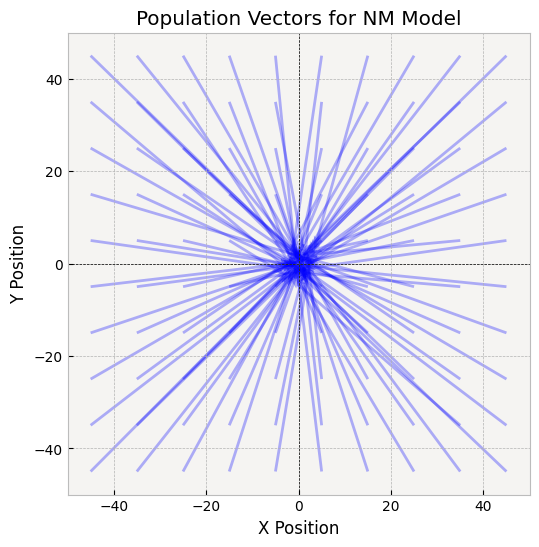


 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+ RUNNING SIMULATIONS FOR DISTORTION=stretch-global-2 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+


Simulating trials: 100%|██████████| 100/100 [00:01<00:00, 75.71it/s]


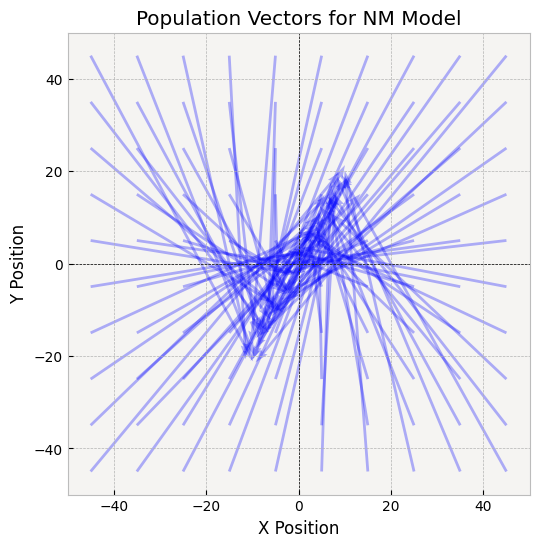


 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+ RUNNING SIMULATIONS FOR DISTORTION=stretch-global-3 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+


Simulating trials: 100%|██████████| 100/100 [00:01<00:00, 76.38it/s]


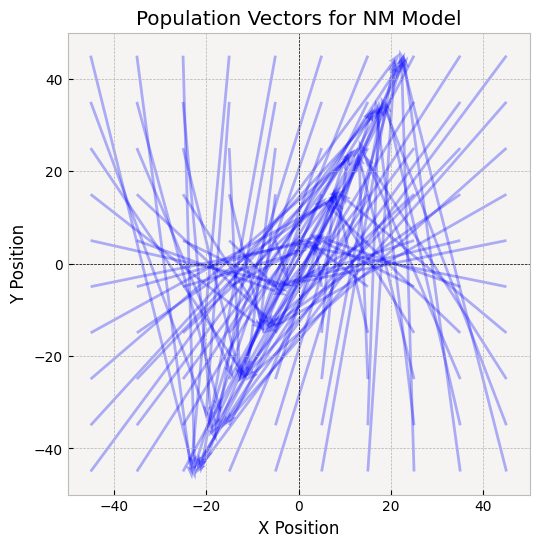


 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+ RUNNING SIMULATIONS FOR DISTORTION=stretch-global-4 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+


Simulating trials: 100%|██████████| 100/100 [00:01<00:00, 76.74it/s]


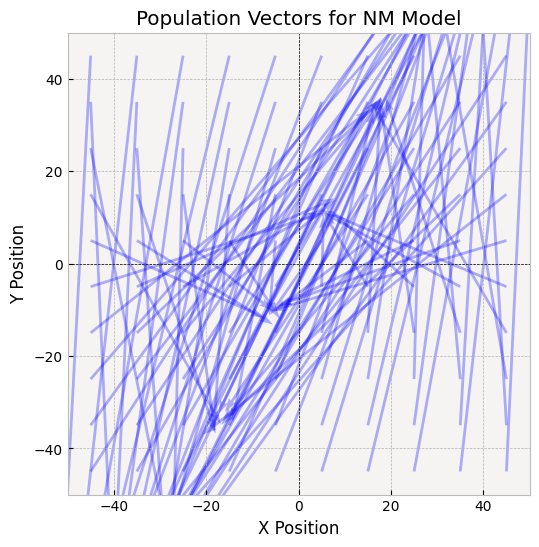


 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+ RUNNING SIMULATIONS FOR DISTORTION=stretch-global-5 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+


Simulating trials: 100%|██████████| 100/100 [00:01<00:00, 76.51it/s]


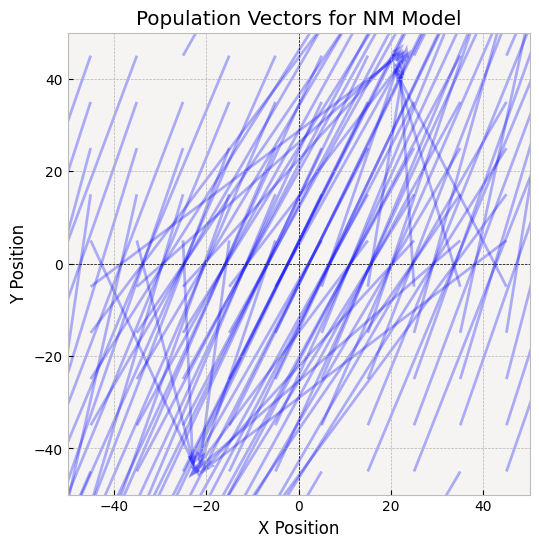

In [ ]:
import numpy as np
from math import pow
import matplotlib.pyplot as plt
plt.style.use('bmh')
# Set background color to antique white
plt.rcParams['axes.facecolor'] = "#F5F4F2"
import os
from utils import *
from utils import grid_to_real_projection
from simulation import *
from tqdm import tqdm
from pprint import pprint

from models import DistanceCellModel, VectorCellModel, NestedModel
from simulation import run_load_simulation
OUTPUT_DIR = 'simulation_outputs'

N_SIM_ROUND = 5
N_TRIALS = 100
ARENA_WIDTH = 100
STEP_SIZE = 1
CONV_THRESH = STEP_SIZE * 1.5
HEX_PROJ=True
model_names = ['nm', 'dcm', 'vcm']


def pop_vec_simulation(model_name, arena_width, n_trials=400, step_size=0.1, convergence_threshold = 2.5, distortion_params = None, hexagonal_projection=False, n_sim_round=1, save_data=True):

    # Directories
    output_dir = Path('simulation_outputs', f'round-{n_sim_round}')
    distortion, a, b = distortion_params['distortion'], distortion_params['a'], distortion_params['b']
    distortion_type = distortion.split('-')[1]
    distortion_text = f'_{distortion}_a-{a}_b-{b}' if distortion is not None else '_undistorted'
    if '+drift' in distortion:
        distortion_text += f'_bdrift-{distortion_params["b_drift"]}'

    #Initialize corresponding model
    if model_name == 'dcm':
        model = DistanceCellModel(distortion_params=distortion_params)
    elif model_name == 'vcm':
        model = VectorCellModel(distortion_params=distortion_params, arena_width = arena_width)
    elif model_name == 'nm':
        model = NestedModel(distortion_params=distortion_params)
    else:
        raise ValueError("Invalid model name")


    # Get evenly spaced start positions in real space
    border_offset = 0.05 * arena_width
    square_half_width = (arena_width / 2)
    offset_square_half_width = square_half_width - border_offset
    xs = np.linspace(-offset_square_half_width, offset_square_half_width, int(np.sqrt(n_trials)))
    ys = np.linspace(-offset_square_half_width, offset_square_half_width, int(np.sqrt(n_trials)))
    XS, YS = np.meshgrid(xs, ys)
    real_start_locs = np.array([XS.ravel(), YS.ravel()]).T.reshape(-1, 2)

    # Get start positions in grid space
    if hexagonal_projection:
        grid_start_locs = real_to_grid_projection(np.array([XS.ravel(), YS.ravel()]) , l1=1, l2=2).T  
    
    # For each trial...
    pop_vec_histories = []
    for i in tqdm(range(n_trials), desc="Simulating trials"):

        # 1) Get start and goal positions 
        real_start_x, real_start_y = real_start_locs[i]
        grid_start_x, grid_start_y = grid_start_locs[i] if hexagonal_projection else (real_start_x, real_start_y)
        goal_x, goal_y = [0, 0] # Goal is the same in real and grid space
 
        # Compute the population vector based on the current position and the goal
        grid_start_x, grid_start_y = real_to_grid_projection([real_start_x, real_start_y]) if hexagonal_projection else (real_start_x, real_start_y)
        curr_pop_vec = model.forward(start_pos=[grid_start_x, grid_start_y], targ_pos=[goal_x, goal_y])
        curr_pop_vec = grid_to_real_projection(curr_pop_vec) if hexagonal_projection else curr_pop_vec
        pop_vec_histories.append(curr_pop_vec)

    # Plot pop_vec_histories
    pop_vec_histories = np.array(pop_vec_histories)
    plt.figure(figsize=(6, 6))
    plt.quiver(real_start_locs[:, 0], real_start_locs[:, 1], pop_vec_histories[:, 0], pop_vec_histories[:, 1], angles='xy', scale_units='xy', color='blue', alpha=0.3, scale=1)
  #  plt.scatter(real_start_locs[:, 0] - pop_vec_histories[:, 0],real_start_locs[:, 1] - pop_vec_histories[:, 1], c='red', s=1, label='Population Vector Endpoints')


    plt.xlim(-square_half_width, square_half_width)
    plt.ylim(-square_half_width, square_half_width)
    plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
    plt.axvline(0, color='black', linewidth=0.5, linestyle='--')
    plt.title(f'Population Vectors for {model_name.upper()} Model')
    plt.xlabel('X Position')
    plt.ylabel('Y Position')
    plt.gca().set_aspect('equal', adjustable='box')
    plt.grid(True)
    plt.show()
stretch_global_params = get_param_dict({'a': [1], 'b': [1, 0.7, 0.5, 0.3, 0.1]}, 
                                       'stretch-global', incl_undistorted=False)

selected_distortion_params = stretch_global_params
for distortion_name in selected_distortion_params.keys():
    print(F'\n {"-+" * 30} RUNNING SIMULATIONS FOR DISTORTION={distortion_name} {"-+" * 30}')
    for model_name in ['nm']:
        pop_vec_simulation(model_name, 
                            arena_width=ARENA_WIDTH, 
                            step_size=STEP_SIZE,
                            convergence_threshold=CONV_THRESH,
                            n_trials=100, 
                            distortion_params=selected_distortion_params[distortion_name],
                            hexagonal_projection=True,
                            n_sim_round= N_SIM_ROUND,
                            save_data=False)